<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day10-discussion-3.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 10, Part 3 discussion — Can you read a fold from its contact map?

The book page showed the contact map of hemoglobin's β chain, an
all-α protein. Here are three real proteins from the PDB, one from each
major fold class:

- **4HHB chain B**: β-globin, all α-helices (Day 7);
- **1TEN**: a fibronectin type III domain of tenascin, all β-strands;
- **1UBQ**: ubiquitin, a mixed α/β protein.

**Before running:** sketch what you expect a β-sheet to look like in a
contact map. Two neighbouring strands run either in the same direction
(parallel) or in opposite directions (antiparallel). How would each
appear?

4HHB β-globin (all α)        146 residues,  197 contacts (|i-j| >= 6),  150 long-range = 1.03 per residue
1TEN FNIII domain (all β)     89 residues,  223 contacts (|i-j| >= 6),  126 long-range = 1.42 per residue
1UBQ ubiquitin (α/β)          76 residues,  139 contacts (|i-j| >= 6),   81 long-range = 1.07 per residue


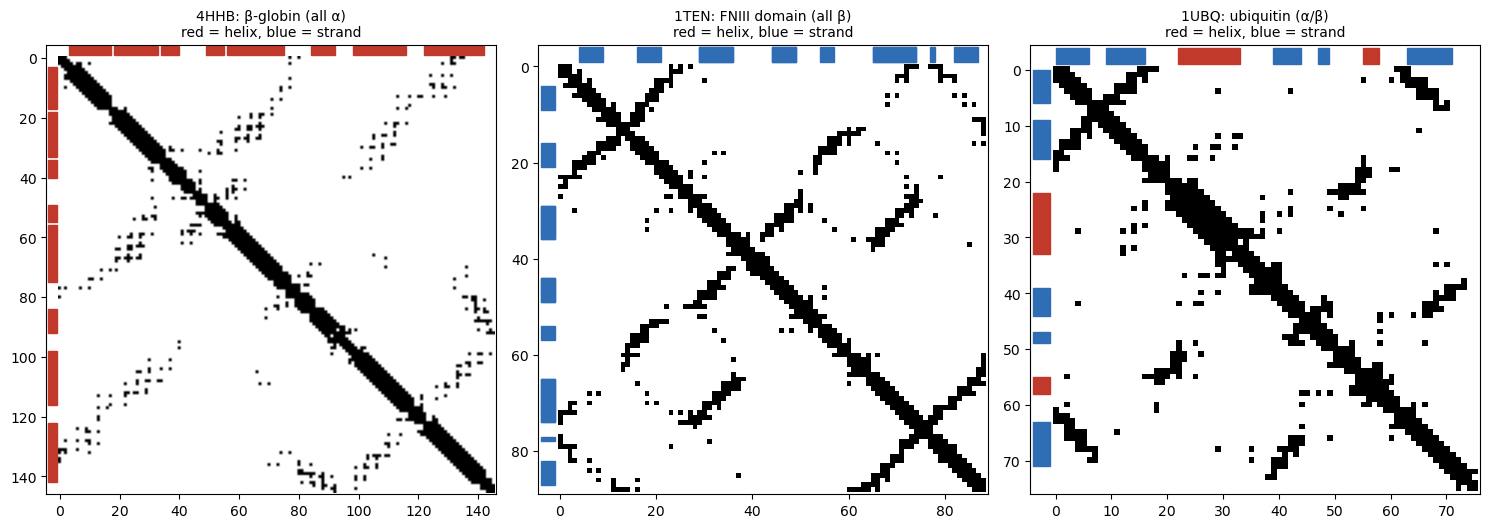

In [1]:
import io, requests
import numpy as np
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser

def contact_map(pdb_id, chain_id, cutoff=8.0):
    text = requests.get(f"https://files.rcsb.org/download/{pdb_id}.pdb", timeout=60).text
    chain = PDBParser(QUIET=True).get_structure(pdb_id, io.StringIO(text))[0][chain_id]
    residues = [r for r in chain if r.id[0] == " " and "CA" in r]
    xyz = np.array([(r["CB"] if "CB" in r else r["CA"]).coord for r in residues])
    contacts = np.linalg.norm(xyz[:, None] - xyz[None], axis=2) < cutoff
    first = residues[0].id[1]
    helices = [(int(l[21:25]) - first, int(l[33:37]) - first) for l in text.splitlines()
               if l.startswith("HELIX") and l[19] == chain_id]
    strands = [(int(l[22:26]) - first, int(l[33:37]) - first) for l in text.splitlines()
               if l.startswith("SHEET") and l[21] == chain_id]
    return contacts, helices, strands

proteins = [("4HHB", "B", "β-globin (all α)"), ("1TEN", "A", "FNIII domain (all β)"),
            ("1UBQ", "A", "ubiquitin (α/β)")]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, (pid, ch, label) in zip(axes, proteins):
    C, helices, strands = contact_map(pid, ch)
    L = len(C)
    i, j = np.triu_indices(L, 6)
    n_long = C[i, j][(j - i) >= 24].sum()
    print(f"{pid} {label:22s} {L:4d} residues, {C[i, j].sum():4d} contacts (|i-j| >= 6), "
          f"{n_long:4d} long-range = {n_long / L:.2f} per residue")
    ax.imshow(C, cmap="Greys", origin="upper")
    for segs, color in [(helices, "#c0392b"), (strands, "#2f6db5")]:
        for a, b in segs:
            ax.add_patch(plt.Rectangle((a, -4), b - a, 3, color=color, clip_on=False))
            ax.add_patch(plt.Rectangle((-4, a), 3, b - a, color=color, clip_on=False))
    ax.set_xlim(-4.5, L); ax.set_ylim(L, -4.5)
    ax.set_title(f"{pid}: {label}\nred = helix, blue = strand", fontsize=10)
plt.tight_layout(); plt.show()

**Discuss:**

1. In 1TEN, find lines running *perpendicular* to the diagonal and lines
   running *parallel* to it. Which ones are antiparallel strand pairs,
   which parallel? Does ubiquitin have both?
2. The β-sandwich has far more long-range contacts per residue than the
   globin. Why do β-sheets in particular produce long-range contacts?
3. Coevolution methods predict contacts one residue pair at a time. Why
   did it help so much (CASP12-13) to predict the *whole map at once*
   with a deep CNN, which can learn these line and block patterns?